In [ ]:
import os
os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

import numpy as np
import matplotlib.pyplot as plt
import scripts.phot_toolkits as phot_tk
from astropy.io import fits
from astropy.stats import knuth_bin_width

JWST_files = phot_tk.Pipeline_level_2_data(working_directory = "/net/vdesk/data2/slagter/JWST_NIRCAM_#1227_level_2/mastDownload/JWST")
%load_ext autoreload
%autoreload 2

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [2]:
catalogue_path  = 'Photometry/NGC346_NIRCam_and_MIRI_Public_JWST_Catalogue.fits'
Catalogue       = phot_tk.Read_Catalogue(catalogue_path = catalogue_path)
Catalogue.show_headers()


--- HEADER EXTENSIE 0 (PRIMARY) ---
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  


--- HEADER EXTENSIE 1 () ---
XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  264 / length of dimension 1                          
NAXIS2  =               249519 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   29 / number of

In [7]:
filter  = 'F200W'

mask    = (Catalogue.cat_data[1].data[filter] < 50)

samples = Catalogue.cat_data[1].data[filter][mask]
N_samples = len(samples)


fig = plt.figure()
gs = fig.add_gridspec(1, 1, figure=fig, wspace=0, hspace=0)
ax0 = fig.add_subplot(gs[0, 0])

dx, bin_edges = knuth_bin_width(samples, return_bins=True)

print(len(bin_edges))
hist = np.histogram(samples, bins=bin_edges)[0]

ax0.stairs(
    hist,
    edges=bin_edges, fill=False, label=filter, lw=2, edgecolor='black'
    )

ax0.text(
        0.05,
        0.95,
        f'Total = {N_samples}',
        transform=ax0.transAxes,
        fontsize=16,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=1),
    )
ax0.set_xlabel("Vega Magnitude")
ax0.set_ylabel("Count")
ax0.set_ylim(0, 12500)
fig.suptitle(f"Detected sources in {filter} ")
plt.show()

AttributeError: 'FITS_record' object has no attribute 'data'

In [41]:
X_color =  catalogue[1].data['F115W'] - catalogue[1].data['F200W']
Y_color = catalogue[1].data['F115W'] - catalogue[1].data['F187N']

X_color_acc = X_color[catalogue[1].data['Pa-alpha_excess'] == 'Y']
Y_color_acc = Y_color[catalogue[1].data['Pa-alpha_excess'] == 'Y']




(-0.5, 6.0)

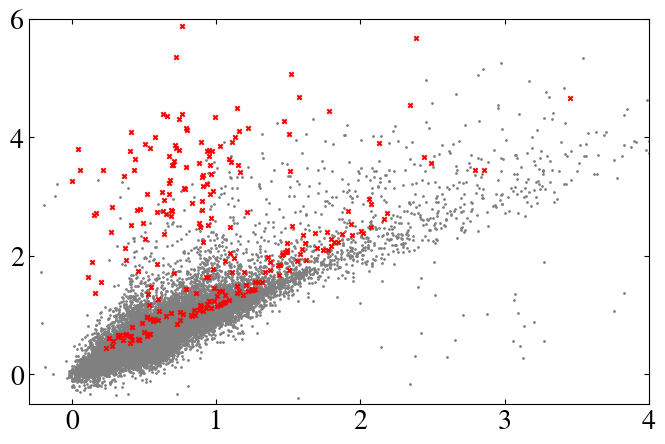

In [46]:

plt.scatter( x = X_color,
             y = Y_color,
             c = 'gray', s=1, alpha=1)

plt.scatter( x = X_color_acc,
             y = Y_color_acc,
             c = 'red', s=10, alpha=1, marker='x')


plt.xlim(-0.3, 4)
plt.ylim(-0.5, 6)

In [ ]:
sort_idx = np.argsort(Y_color)
X_sorted = X_color[sort_idx]
Y_sorted = Y_color[sort_idx]


from scripts.RunningMedian import RunningMedian

WINDOW_SIZE = 1000

w           = RunningMedian(window_size = WINDOW_SIZE )

w.insert(Y_sorted)
plt.plot(X_sorted, w.median())